In [26]:
import numpy as np
from matplotlib import pyplot as plt
import  pandas as pd
from sklearn.mixture import GaussianMixture

In [10]:
earth_mass = 5.972e+27
earth_radius = 6.37e+8

In [55]:
df = pd.read_csv('exoplanets.csv', comment='#')

In [56]:
df = df[['pl_rade', 'pl_masse', 'pl_dens', 'pl_orbsmax', 'st_mass']].copy()

In [58]:
df.dropna(inplace=True, subset=['pl_rade', 'pl_masse', 'pl_orbsmax', 'st_mass'])

In [59]:
df['pl_dens_calc'] = df['pl_masse']*earth_mass/(4./3*np.pi*(df['pl_rade']*earth_radius)**3)

In [60]:
df.drop(['pl_dens'], axis=1, inplace=True)

In [61]:
data_arr = np.log10(df.values)

In [62]:
data_arr_norm = data_arr/np.mean(data_arr, axis=0)

In [65]:
gm = GaussianMixture(n_components=4, random_state=0).fit(data_arr_norm)

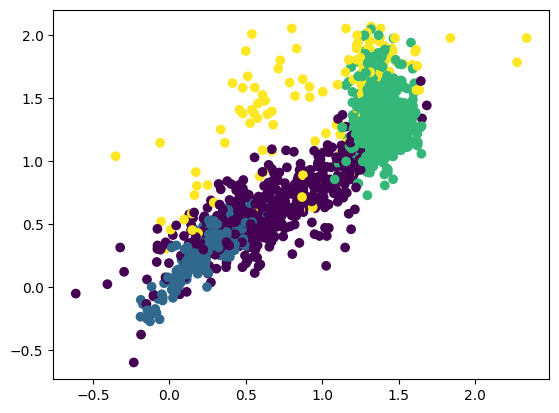

In [66]:
plt.scatter(data_arr_norm[:, 0], data_arr_norm[:, 1], c=gm.fit_predict(data_arr_norm))

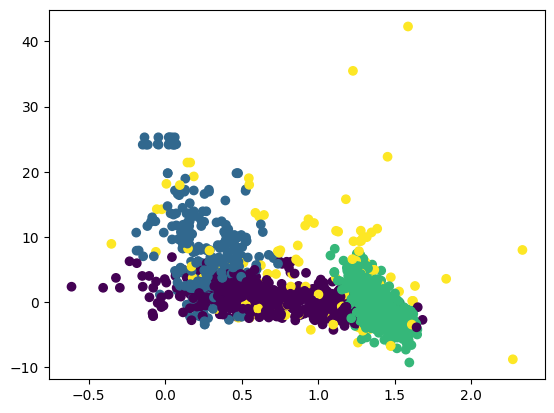

In [67]:
plt.scatter(data_arr_norm[:, 0], data_arr_norm[:, 3], c=gm.fit_predict(data_arr_norm))